In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, math, pickle, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 12,
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
Device: cuda
GPU: Tesla T4


In [2]:
DATA_DIR = '/content/drive/MyDrive/LSTGAN_Data/results'

CKPT_PATH  = os.path.join(DATA_DIR, 'best_lstgan.pt')
GRAPH_FILE = os.path.join(DATA_DIR, 'adj_mx_bay.pkl')
TRAIN_FILE = os.path.join(DATA_DIR, 'train_5min.pkl')
VAL_FILE   = os.path.join(DATA_DIR, 'val_5min.pkl')
TEST_FILE  = os.path.join(DATA_DIR, 'test_5min.pkl')

for name, path in [('Checkpoint', CKPT_PATH), ('Graph', GRAPH_FILE),
                    ('Train', TRAIN_FILE), ('Val', VAL_FILE), ('Test', TEST_FILE)]:
    exists = os.path.exists(path)
    print(f'  {name:12s}: {"✓" if exists else "✗ MISSING"} {path}')

NUM_SENSORS      = 325
STEPS_PER_HOUR   = 12
STEPS_PER_DAY    = 288

WEEKLY_WINDOW    = 2016
DAILY_WINDOW     = 288
HOURLY_WINDOW    = 12
FORECAST_HORIZON = 12
EVAL_HORIZONS    = [3, 6, 12]  # H3=15min, H6=30min, H12=60min

WEEKLY_IN_CHANNELS  = 3;  WEEKLY_OUT_CHANNELS  = 16
DAILY_IN_CHANNELS   = 3;  DAILY_OUT_CHANNELS   = 8
HOURLY_IN_CHANNELS  = 1

WEEKLY_STRIDE_1 = 14; WEEKLY_STRIDE_2 = 12
DAILY_STRIDE_1  = 4;  DAILY_STRIDE_2  = 6

SPATIAL_EMBED_DIM       = 16
GLOBAL_SPATIAL_CHANNELS = 16; GLOBAL_ATTN_HEADS = 4; GLOBAL_ATTN_LAYERS = 1
LOCAL_SPATIAL_CHANNELS  = 8;  CHEBYSHEV_K = 5;      GCN_LAYERS = 1

D_MODEL = WEEKLY_OUT_CHANNELS + DAILY_OUT_CHANNELS + GLOBAL_SPATIAL_CHANNELS + LOCAL_SPATIAL_CHANNELS  # 48
TIME_ONEHOT_DIM = 7 + STEPS_PER_DAY  # 295
DECODER_HEADS = 6; DECODER_HEAD_DIM = 8; DECODER_LAYERS = 1

BATCH_SIZE = 8

print(f'\nD_MODEL={D_MODEL}, TIME_DIM={TIME_ONEHOT_DIM}, HORIZON={FORECAST_HORIZON}')

  Checkpoint  : ✓ /content/drive/MyDrive/LSTGAN_Data/results/best_lstgan.pt
  Graph       : ✓ /content/drive/MyDrive/LSTGAN_Data/results/adj_mx_bay.pkl
  Train       : ✓ /content/drive/MyDrive/LSTGAN_Data/results/train_5min.pkl
  Val         : ✓ /content/drive/MyDrive/LSTGAN_Data/results/val_5min.pkl
  Test        : ✓ /content/drive/MyDrive/LSTGAN_Data/results/test_5min.pkl

D_MODEL=48, TIME_DIM=295, HORIZON=12


In [3]:
class TrafficDataset(Dataset):
    """Multi-scale traffic forecasting dataset at 5-min resolution."""
    def __init__(self, data_df, mode='train', mean=None, std=None):
        self.mode = mode
        self.num_sensors = data_df.shape[1]
        self.mean = data_df.values.mean() if mean is None else mean
        self.std  = data_df.values.std()  if std  is None else std
        self.speed = ((data_df.values - self.mean) / (self.std + 1e-8)).astype(np.float32)
        if hasattr(data_df.index, 'weekday'):
            self.day_of_week = data_df.index.weekday.values    # 0-6
            self.time_of_day = (data_df.index.hour * 12 + data_df.index.minute // 5).values  # 0-287
        else:
            T = len(data_df)
            self.day_of_week = np.arange(T) % 7
            self.time_of_day = np.arange(T) % STEPS_PER_DAY
        self.total_steps = len(self.speed)
        self.start_offset = WEEKLY_WINDOW
        self.valid_len = self.total_steps - self.start_offset - FORECAST_HORIZON + 1
        assert self.valid_len > 0, f'Not enough data: {self.total_steps} steps'
        print(f'[{mode}] {self.total_steps} steps, {self.valid_len} samples, {self.num_sensors} sensors')

    def __len__(self): return self.valid_len

    def _time_feats(self, idx, length):
        s = idx - length
        dow = self.day_of_week[s:idx].astype(np.float32) / 6.0
        tod = self.time_of_day[s:idx].astype(np.float32) / 287.0
        return np.stack([dow, tod], axis=-1)

    def __getitem__(self, idx):
        t = self.start_offset + idx
        N = self.num_sensors

        sp_w = self.speed[t-WEEKLY_WINDOW:t]
        tf_w = self._time_feats(t, WEEKLY_WINDOW)
        X_w = np.stack([sp_w, np.tile(tf_w[:,0:1],(1,N)), np.tile(tf_w[:,1:2],(1,N))], axis=-1)

        sp_d = self.speed[t-DAILY_WINDOW:t]
        tf_d = self._time_feats(t, DAILY_WINDOW)
        X_d = np.stack([sp_d, np.tile(tf_d[:,0:1],(1,N)), np.tile(tf_d[:,1:2],(1,N))], axis=-1)

        X_h = self.speed[t-HOURLY_WINDOW:t][:,:,np.newaxis]

        t_info = np.array([self.day_of_week[t], self.time_of_day[t]], dtype=np.int64)

        Y = self.speed[t:t+FORECAST_HORIZON][:,:,np.newaxis]
        return (torch.from_numpy(X_w), torch.from_numpy(X_d), torch.from_numpy(X_h),
                torch.from_numpy(t_info), torch.from_numpy(Y))


def load_adjacency_matrix(path=GRAPH_FILE):
    with open(path, 'rb') as f:
        adj = pickle.load(f, encoding='latin1')
    if isinstance(adj, (tuple, list)):
        adj = adj[2] if len(adj) >= 3 else adj[-1]
    return adj.astype(np.float32) if isinstance(adj, np.ndarray) else adj


def get_edge_info(adj_mx):
    rows, cols = np.nonzero(adj_mx)
    return torch.LongTensor(np.stack([rows, cols])), torch.FloatTensor(adj_mx[rows, cols])

print('Dataset module ready.')

Dataset module ready.


In [4]:

class TemporalEncoder(nn.Module):
    def __init__(self, in_ch, out_ch, s1, s2):
        super().__init__()
        mid = max((in_ch + out_ch)//2, 8)
        self.c1a = nn.Conv1d(in_ch, mid, 3, padding=1)
        self.c1b = nn.Conv1d(mid, mid, s1, stride=s1) if s1>1 else nn.Identity()
        self.bn1 = nn.BatchNorm1d(mid)
        self.c2a = nn.Conv1d(mid, out_ch, 3, padding=1)
        self.c2b = nn.Conv1d(out_ch, out_ch, s2, stride=s2) if s2>1 else nn.Identity()
        self.bn2 = nn.BatchNorm1d(out_ch)
    def forward(self, x):
        B,T,N,C = x.shape
        x = x.permute(0,2,3,1).reshape(B*N, C, T)
        x = F.relu(self.bn1(self.c1b(F.relu(self.c1a(x)))))
        x = self.bn2(self.c2b(F.relu(self.c2a(x))))
        _,Co,To = x.shape
        return x.reshape(B,N,Co,To).permute(0,3,1,2)


class SpatialEmbedding(nn.Module):
    def __init__(self, in_ch=HOURLY_IN_CHANNELS, out_ch=SPATIAL_EMBED_DIM):
        super().__init__()
        self.conv = nn.Conv1d(in_ch, out_ch, 1)
        self.bn = nn.BatchNorm1d(out_ch)
    def forward(self, x):
        B,T,N,C = x.shape
        x = x.reshape(B*T, N, C).permute(0,2,1)
        x = self.bn(self.conv(x))
        return x.permute(0,2,1).reshape(B,T,N,-1)

class GlobalSpatialEncoder(nn.Module):
    def __init__(self, d=SPATIAL_EMBED_DIM, heads=GLOBAL_ATTN_HEADS, nl=GLOBAL_ATTN_LAYERS, out_ch=GLOBAL_SPATIAL_CHANNELS):
        super().__init__()
        self.layers = nn.ModuleList()
        for _ in range(nl):
            self.layers.append(nn.ModuleDict({
                'attn': nn.MultiheadAttention(d, heads, batch_first=True, dropout=0.1),
                'n1': nn.LayerNorm(d), 'n2': nn.LayerNorm(d),
                'ffn': nn.Sequential(nn.Linear(d,d*4), nn.GELU(), nn.Dropout(0.1), nn.Linear(d*4,d))}))
        self.proj = nn.Linear(d, out_ch) if d != out_ch else nn.Identity()
    def forward(self, x):
        B,T,N,C = x.shape
        x = x.reshape(B*T, N, C)
        for l in self.layers:
            a,_ = l['attn'](x,x,x); x = l['n1'](x+a); x = l['n2'](x+l['ffn'](x))
        return self.proj(x).reshape(B,T,N,-1)

class ManualChebConv(nn.Module):
    def __init__(self, in_ch, out_ch, K=CHEBYSHEV_K):
        super().__init__()
        self.K = K
        self.weights = nn.ParameterList([nn.Parameter(torch.empty(in_ch, out_ch)) for _ in range(K)])
        self.bias = nn.Parameter(torch.zeros(out_ch))
        for w in self.weights: nn.init.xavier_uniform_(w)
    def forward(self, x, L):
        Z0, Z1 = x, L @ x
        out = Z0 @ self.weights[0]
        if self.K > 1: out = out + Z1 @ self.weights[1]
        for k in range(2, self.K):
            Zk = 2*L@Z1 - Z0; out = out + Zk@self.weights[k]; Z0, Z1 = Z1, Zk
        return out + self.bias

class LocalSpatialEncoder(nn.Module):
    def __init__(self, in_ch=SPATIAL_EMBED_DIM, out_ch=LOCAL_SPATIAL_CHANNELS, K=CHEBYSHEV_K):
        super().__init__()
        self.cheb = ManualChebConv(in_ch, out_ch, K)
        self.register_buffer('L_scaled', None)

    def set_graph(self, adj_mx):
        A = adj_mx
        D_inv = np.diag(1.0/np.sqrt(np.maximum(A.sum(1), 1e-8)))
        L = np.eye(A.shape[0]) - D_inv @ A @ D_inv
        eig = np.linalg.eigvalsh(L)
        device = next(self.parameters()).device
        self.L_scaled = torch.FloatTensor(2*L/(eig[-1]+1e-8) - np.eye(A.shape[0])).to(device)

    def forward(self, x, edge_index=None, edge_weight=None):
        B,T,N,C = x.shape; L = self.L_scaled.to(x.device)
        x = x.reshape(B*T, N, C)
        out = self.cheb(x, L)
        return out.reshape(B,T,N,-1)

class TimeEncoder(nn.Module):
    def __init__(self, d=D_MODEL, tdim=TIME_ONEHOT_DIM):
        super().__init__()
        h = d*2
        self.mlp = nn.Sequential(nn.Linear(tdim,h), nn.Linear(h,h), nn.ReLU(), nn.Linear(h,d))
        self.norm = nn.LayerNorm(d)
    def forward(self, ste, time_info):
        B,T,N,d = ste.shape
        dow = F.one_hot(time_info[:,0].long(), 7).float()
        tod = F.one_hot(time_info[:,1].long(), 288).float()
        vt = self.mlp(torch.cat([dow,tod],-1))[:,None,None,:].expand_as(ste)
        return self.norm(ste + vt)

class PositionalEncoding(nn.Module):
    def __init__(self, d, maxlen=500):
        super().__init__()
        pe = torch.zeros(maxlen, d)
        pos = torch.arange(maxlen).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d,2).float()*(-math.log(10000.0)/d))
        pe[:,0::2] = torch.sin(pos*div); pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:,:x.size(1),:]

class TemporalDecoder(nn.Module):
    def __init__(self, d=D_MODEL, heads=DECODER_HEADS, nl=DECODER_LAYERS, H=FORECAST_HORIZON):
        super().__init__()
        self.H = H; self.pe = PositionalEncoding(d)
        self.enc_layers = nn.ModuleList()
        self.dec_layers = nn.ModuleList()
        for _ in range(nl):
            self.enc_layers.append(nn.ModuleDict({
                'attn': nn.MultiheadAttention(d, heads, batch_first=True, dropout=0.1),
                'n1':nn.LayerNorm(d),'n2':nn.LayerNorm(d),
                'ffn':nn.Sequential(nn.Linear(d,d*4),nn.GELU(),nn.Dropout(0.1),nn.Linear(d*4,d))}))
            self.dec_layers.append(nn.ModuleDict({
                'attn': nn.MultiheadAttention(d, heads, batch_first=True, dropout=0.1),
                'n1':nn.LayerNorm(d),'n2':nn.LayerNorm(d),
                'ffn':nn.Sequential(nn.Linear(d,d*4),nn.GELU(),nn.Dropout(0.1),nn.Linear(d*4,d))}))
        self.fq = nn.Parameter(torch.randn(1, H, d)*0.02)
        self.out_proj = nn.Linear(d, 1)
    def forward(self, ste):
        B,T,N,d = ste.shape
        x = ste.permute(0,2,1,3).reshape(B*N, T, d)
        x = self.pe(x)
        for l in self.enc_layers:
            a,_ = l['attn'](x,x,x); x = l['n1'](x+a); x = l['n2'](x+l['ffn'](x))
        q = self.fq.expand(B*N,-1,-1)
        for l in self.dec_layers:
            a,_ = l['attn'](q,x,x); q = l['n1'](q+a); q = l['n2'](q+l['ffn'](q))
        return self.out_proj(q).reshape(B,N,self.H,1).permute(0,2,1,3)

class LSTGAN(nn.Module):
    def __init__(self, num_sensors=NUM_SENSORS):
        super().__init__()
        self.weekly_enc  = TemporalEncoder(WEEKLY_IN_CHANNELS, WEEKLY_OUT_CHANNELS, WEEKLY_STRIDE_1, WEEKLY_STRIDE_2)
        self.daily_enc   = TemporalEncoder(DAILY_IN_CHANNELS, DAILY_OUT_CHANNELS, DAILY_STRIDE_1, DAILY_STRIDE_2)
        self.sp_embed    = SpatialEmbedding(HOURLY_IN_CHANNELS, SPATIAL_EMBED_DIM)
        self.global_enc  = GlobalSpatialEncoder(SPATIAL_EMBED_DIM, GLOBAL_ATTN_HEADS, GLOBAL_ATTN_LAYERS, GLOBAL_SPATIAL_CHANNELS)
        self.local_enc   = LocalSpatialEncoder(SPATIAL_EMBED_DIM, LOCAL_SPATIAL_CHANNELS, CHEBYSHEV_K)
        self.time_enc    = TimeEncoder(D_MODEL)
        self.decoder     = TemporalDecoder(D_MODEL, DECODER_HEADS, DECODER_LAYERS, FORECAST_HORIZON)

    def _match_time(self, x, tgt):
        T = x.shape[1]
        if T == tgt: return x
        if T > tgt: return x[:,:tgt]
        B,T,N,C = x.shape
        x = x.permute(0,3,2,1).reshape(B*C*N,1,T)
        x = F.interpolate(x, size=tgt, mode='nearest')
        return x.reshape(B,C,N,tgt).permute(0,3,2,1)

    def forward(self, X_w, X_d, X_h, t_info, edge_idx=None, edge_wt=None):
        Xw = self.weekly_enc(X_w)
        Xd = self.daily_enc(X_d)
        Xe = self.sp_embed(X_h)
        Xsa = self.global_enc(Xe)
        Xgcn = self.local_enc(Xe, edge_idx, edge_wt)
        Tt = X_h.shape[1]
        Xw = self._match_time(Xw, Tt)
        Xd = self._match_time(Xd, Tt)
        STe = torch.cat([Xw, Xd, Xsa, Xgcn], dim=-1)
        STE = self.time_enc(STe, t_info)
        return self.decoder(STE)

print('All model components defined.')

All model components defined.


In [5]:
print('Loading data...')
test_df  = pd.read_pickle(TEST_FILE)
adj_mx   = load_adjacency_matrix()

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
train_mean = ckpt['mean']
train_std  = ckpt['std']
print(f'Train stats: mean={train_mean:.2f}, std={train_std:.2f}')
print(f'Checkpoint epoch: {ckpt["epoch"]}, Val MAE: {ckpt["val_mae"]:.4f}')


test_ds = TrafficDataset(test_df, 'test', train_mean, train_std)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

model = LSTGAN().to(DEVICE)
model.load_state_dict(ckpt['model'], strict=False)
model.local_enc.set_graph(adj_mx)

edge_index, edge_weight = get_edge_info(adj_mx)
edge_index = edge_index.to(DEVICE)
edge_weight = edge_weight.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel loaded: {n_params:,} trainable parameters')
print(f'Test batches: {len(test_loader)}')


Loading data...
Train stats: mean=62.74, std=9.44
Checkpoint epoch: 50, Val MAE: 1.5934
[test] 10424 steps, 8397 samples, 325 sensors

Model loaded: 109,428 trainable parameters
Test batches: 1050


In [6]:

train_df = pd.read_pickle(TRAIN_FILE)
val_df = pd.read_pickle(VAL_FILE)
test_df_loaded = pd.read_pickle(TEST_FILE)

train_df.index.freq = None
val_df.index.freq = None
test_df_loaded.index.freq = None

all_df = pd.concat([train_df, val_df, test_df_loaded])
all_speed = ((all_df.values - train_mean) / (train_std + 1e-8)).astype(np.float32)
all_dow = all_df.index.dayofweek.values
all_tod = (all_df.index.hour * 12 + all_df.index.minute // 5).values
all_hod = all_df.index.hour.values
raw_data = all_df.values
print(f'Full dataset: {all_df.shape}, {all_df.index[0]} to {all_df.index[-1]}')


Full dataset: (52116, 325), 2017-01-01 00:00:00 to 2017-06-30 23:55:00


In [7]:
DAYS = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

def predict_at(day_of_week, hour):
    """Predict traffic for all sensors at given day/hour.
    Args: day_of_week (0=Mon..6=Sun), hour (0-23)
    Returns: (12, 325) array of predicted speeds (mph)
    """
    matches = [t for t in range(WEEKLY_WINDOW, len(all_df)-FORECAST_HORIZON)
               if all_dow[t]==day_of_week and all_hod[t]==hour]
    if not matches: return None
    n = min(5, len(matches))
    indices = np.random.choice(matches, n, replace=False)
    preds = []
    for t in indices:
        N = NUM_SENSORS
        sp_w = all_speed[t-WEEKLY_WINDOW:t]
        dw = (all_dow[t-WEEKLY_WINDOW:t] / 6.).astype(np.float32)
        tw = (all_tod[t-WEEKLY_WINDOW:t] / 287.).astype(np.float32)
        X_w = torch.from_numpy(np.stack([sp_w, np.tile(dw[:,None],(1,N)), np.tile(tw[:,None],(1,N))], -1)).unsqueeze(0).to(DEVICE)
        sp_d = all_speed[t-DAILY_WINDOW:t]
        dd = (all_dow[t-DAILY_WINDOW:t] / 6.).astype(np.float32)
        td = (all_tod[t-DAILY_WINDOW:t] / 287.).astype(np.float32)
        X_d = torch.from_numpy(np.stack([sp_d, np.tile(dd[:,None],(1,N)), np.tile(td[:,None],(1,N))], -1)).unsqueeze(0).to(DEVICE)
        X_h = torch.from_numpy(all_speed[t-HOURLY_WINDOW:t][:,:,None]).unsqueeze(0).to(DEVICE)
        ti = torch.tensor([[all_dow[t], all_tod[t]]]).to(DEVICE)
        with torch.no_grad():
            pred = model(X_w, X_d, X_h, ti, edge_index, edge_weight)
            preds.append((pred.cpu().numpy() * train_std + train_mean)[0,:,:,0])
    return np.mean(preds, axis=0)
print('Prediction function ready.')

Prediction function ready.


Predicting traffic for Wednesday at 17:00...


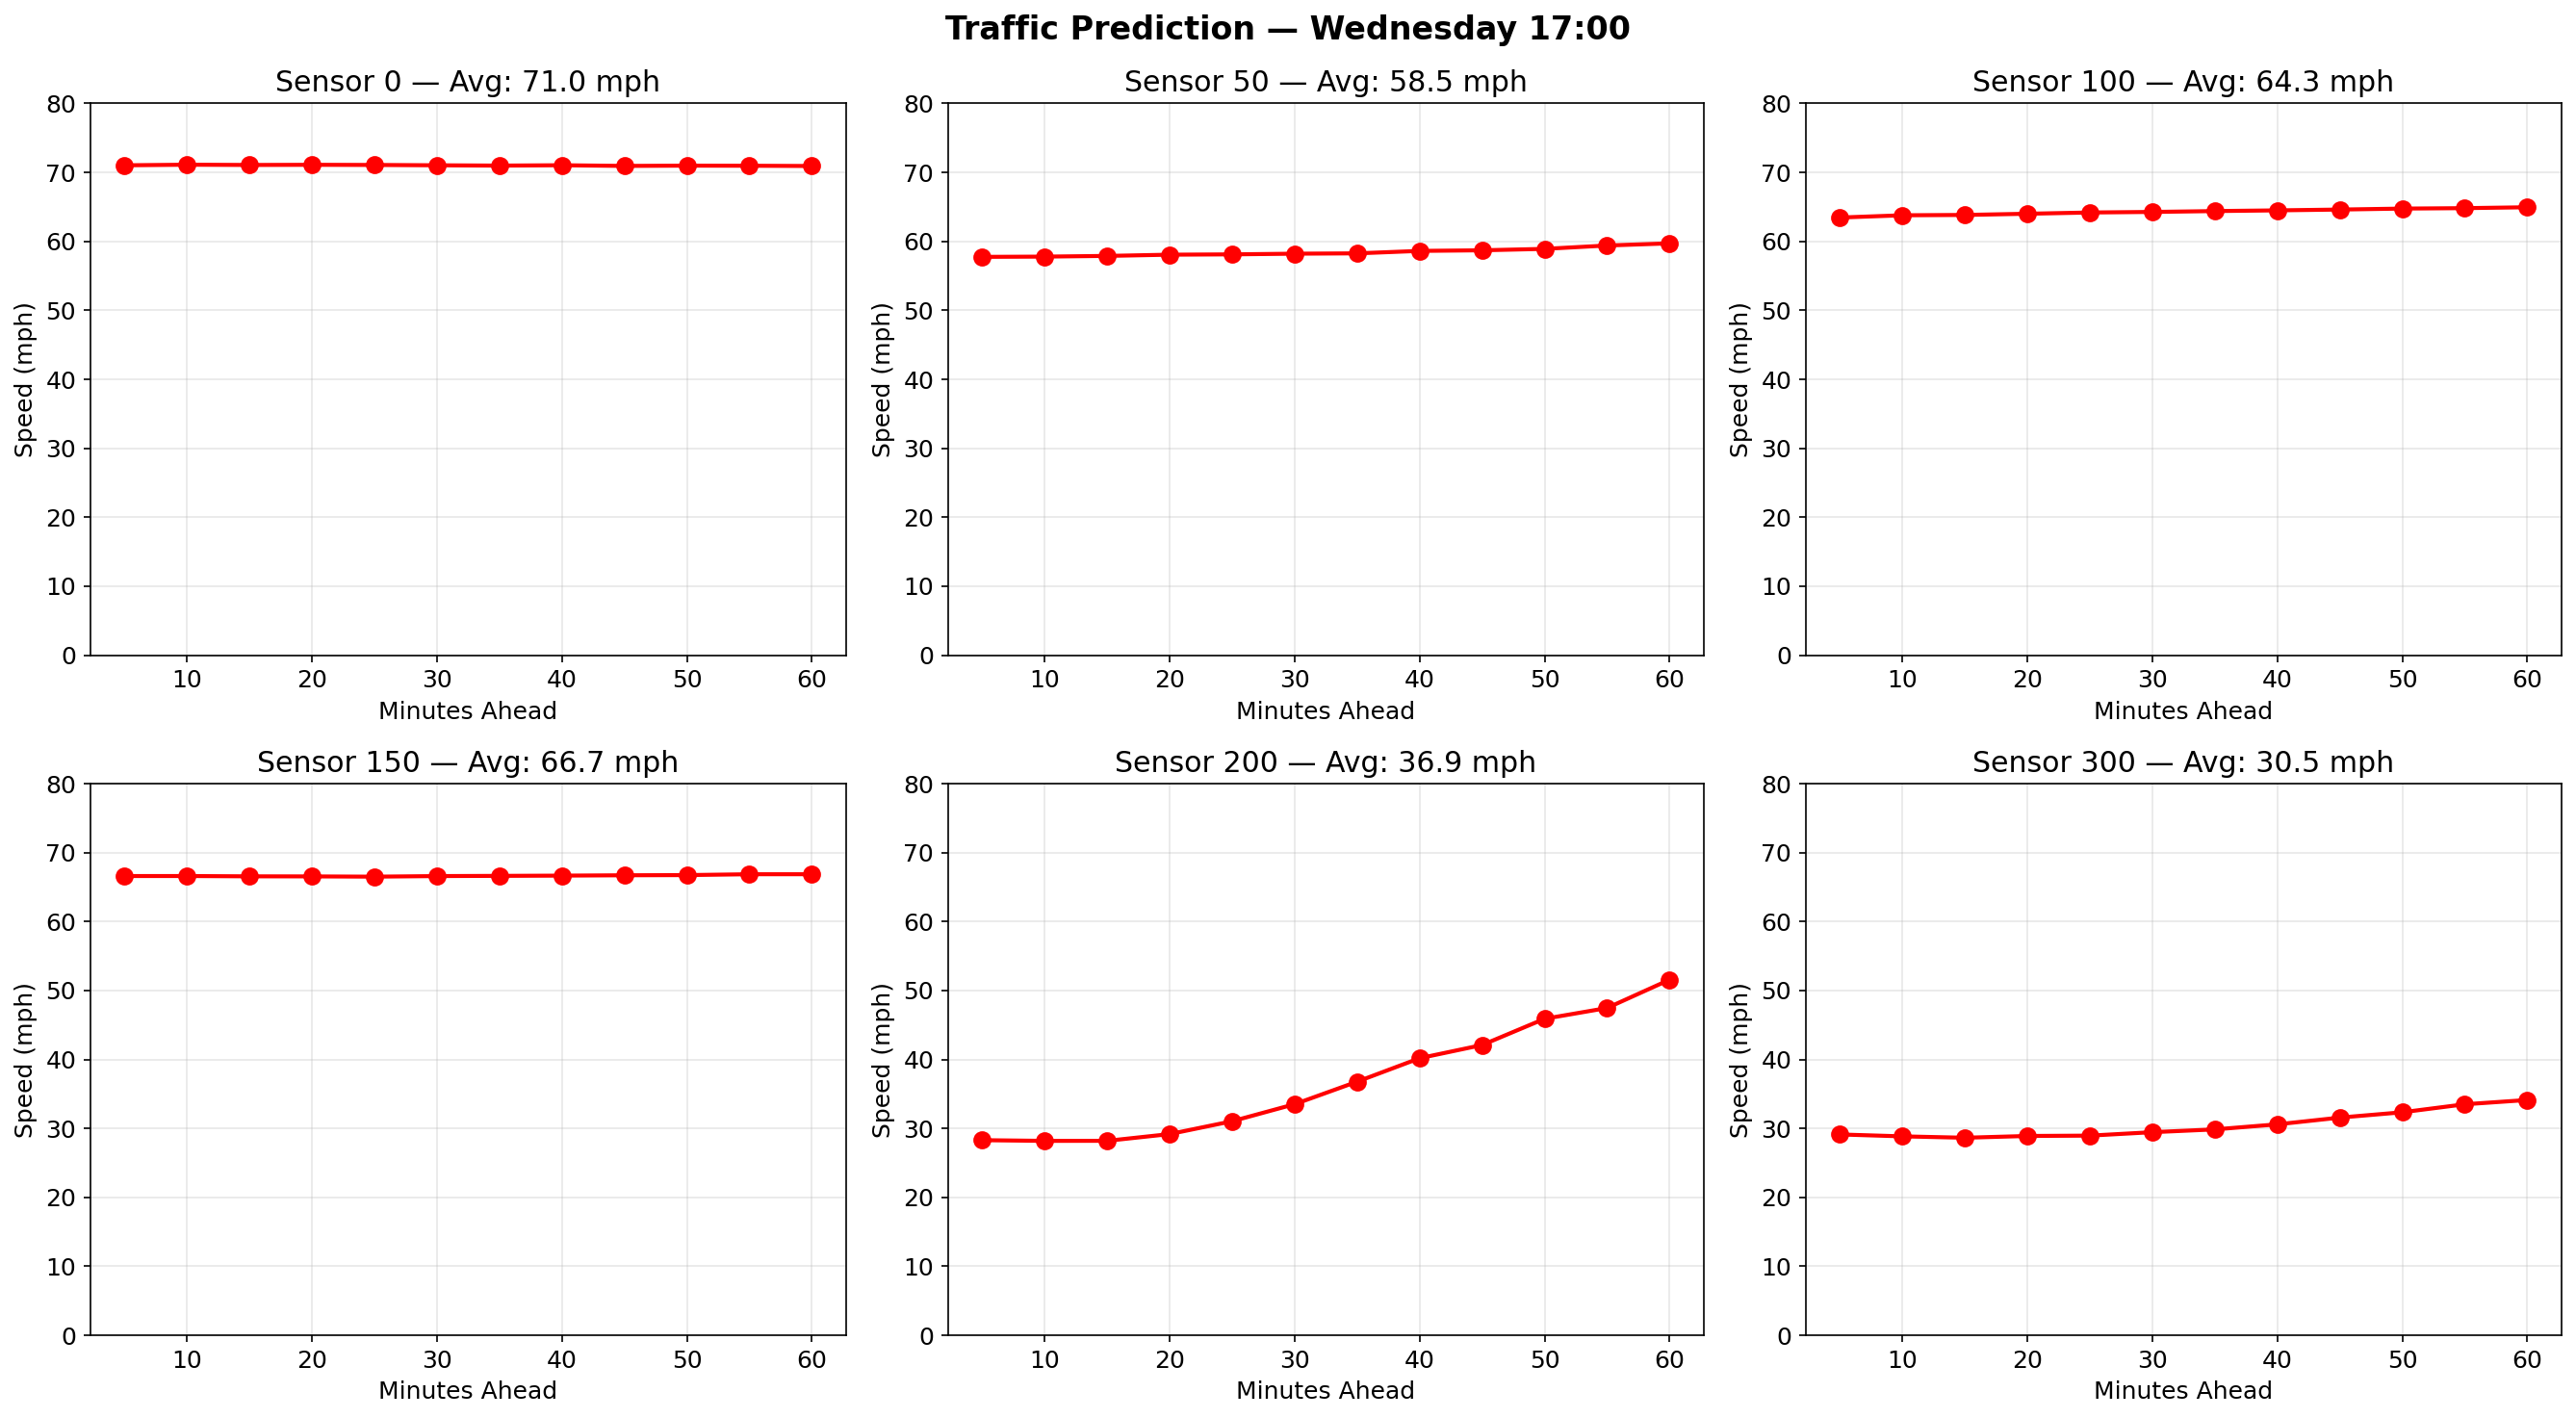


60-min forecast: avg=53.6 mph, congested sensors (<35mph): 40/325


In [8]:
QUERY_DAY  = 2   # 0=Monday, 1=Tuesday, ..., 6=Sunday
QUERY_HOUR = 17   # 0-23

print(f'Predicting traffic for {DAYS[QUERY_DAY]} at {QUERY_HOUR:02d}:00...')
pred = predict_at(QUERY_DAY, QUERY_HOUR)
if pred is not None:
    steps = np.arange(1, FORECAST_HORIZON+1) * 5
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Traffic Prediction — {DAYS[QUERY_DAY]} {QUERY_HOUR:02d}:00', fontsize=16, fontweight='bold')
    for ax, s in zip(axes.flat, [0, 50, 100, 150, 200, 300]):
        ax.plot(steps, pred[:, s], 'ro-', lw=2, markersize=8)
        ax.set_title(f'Sensor {s} — Avg: {pred[:,s].mean():.1f} mph')
        ax.set_xlabel('Minutes Ahead'); ax.set_ylabel('Speed (mph)')
        ax.set_ylim(0, 80); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/demo_prediction.png', dpi=150, bbox_inches='tight'); plt.show()

    # Summary
    avg_speed = pred[-1].mean()
    congested = (pred[-1] < 35).sum()
    print(f'\n60-min forecast: avg={avg_speed:.1f} mph, congested sensors (<35mph): {congested}/{NUM_SENSORS}')

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

@interact(
    day=widgets.Dropdown(options=[(name, i) for i, name in enumerate(DAYS)], value=2, description='Day:'),
    hour=widgets.IntSlider(min=0, max=23, step=1, value=17, description='Hour:'),
    sensor_ids=widgets.SelectMultiple(
        options=list(range(NUM_SENSORS)),
        value=[0, 50, 100, 150, 200, 300],
        description='Sensors:',
        rows=6
    )
)
def update_prediction(day, hour, sensor_ids):
    print(f'Predicting traffic for {DAYS[day]} at {hour:02d}:00')
    pred = predict_at(day, hour)

    if pred is not None:
        steps = np.arange(1, FORECAST_HORIZON+1) * 5
        num_plots = len(sensor_ids)

        if num_plots > 0:
            cols = 3
            rows = (num_plots + cols - 1) // cols
            fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), squeeze=False)
            fig.suptitle(f'Traffic Prediction — {DAYS[day]} {hour:02d}:00', fontsize=16, fontweight='bold')

            ax_flat = axes.flatten()
            selected_speeds = []

            for i, s in enumerate(sensor_ids):
                ax = ax_flat[i]
                sensor_data = pred[:, s]
                ax.plot(steps, sensor_data, 'ro-', lw=2, markersize=8)
                ax.set_title(f'Sensor {s} — Avg: {sensor_data.mean():.1f} mph')
                ax.set_xlabel('Minutes Ahead')
                ax.set_ylabel('Speed (mph)')
                ax.set_ylim(0, 80)
                ax.grid(True, alpha=0.3)
                selected_speeds.append(sensor_data.mean())

            for j in range(i + 1, len(ax_flat)):
                ax_flat[j].axis('off')

            plt.tight_layout()
            plt.show()

            print(f'Selected Sensor :- ')
            print(f'Average Speed for selected sensors: {np.mean(selected_speeds):.1f} mph')

        avg_speed = pred[-1].mean()
        congested = (pred[-1] < 35).sum()
        print(f'\nGlobal Network Summary (All {NUM_SENSORS} Sensors) ')
        print(f'  Network Average Speed: {avg_speed:.1f} mph')
        print(f'  Congested Sensors (<35mph): {congested}/{NUM_SENSORS} ({congested/NUM_SENSORS*100:.1f}%)')
    else:
        print(f'No data matches found for {DAYS[day]} at {hour:02d}:00 in the dataset.')

interactive(children=(Dropdown(description='Day:', index=2, options=(('Monday', 0), ('Tuesday', 1), ('Wednesda…

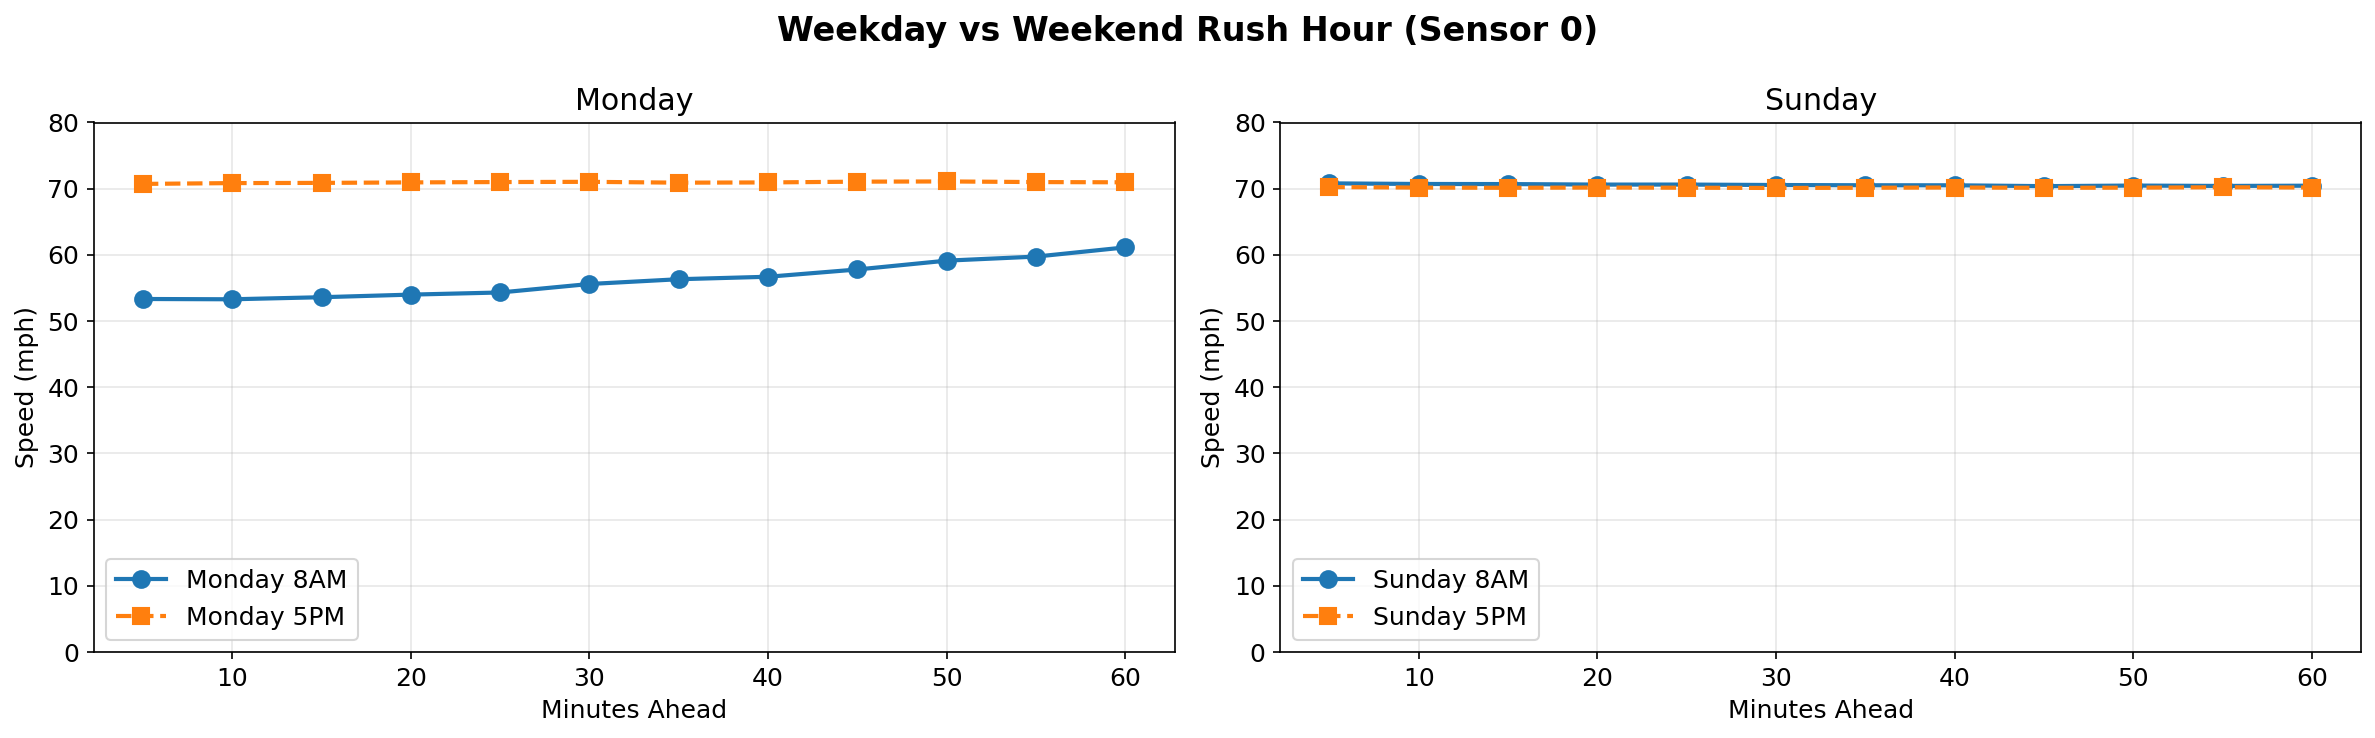

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Weekday vs Weekend Rush Hour (Sensor 0)', fontsize=16, fontweight='bold')
for ax, (day, name) in zip(axes, [(0, 'Monday'), (6, 'Sunday')]):
    p = predict_at(day, 8)
    if p is not None:
        steps = np.arange(1, FORECAST_HORIZON+1) * 5
        ax.plot(steps, p[:, 0], 'o-', lw=2, markersize=8, label=f'{name} 8AM')
    p2 = predict_at(day, 17)
    if p2 is not None:
        ax.plot(steps, p2[:, 0], 's--', lw=2, markersize=8, label=f'{name} 5PM')
    ax.set_title(name); ax.set_xlabel('Minutes Ahead'); ax.set_ylabel('Speed (mph)')
    ax.legend(); ax.set_ylim(0, 80)
plt.tight_layout()
plt.savefig('/content/demo_weekday_weekend.png', dpi=150, bbox_inches='tight'); plt.show()

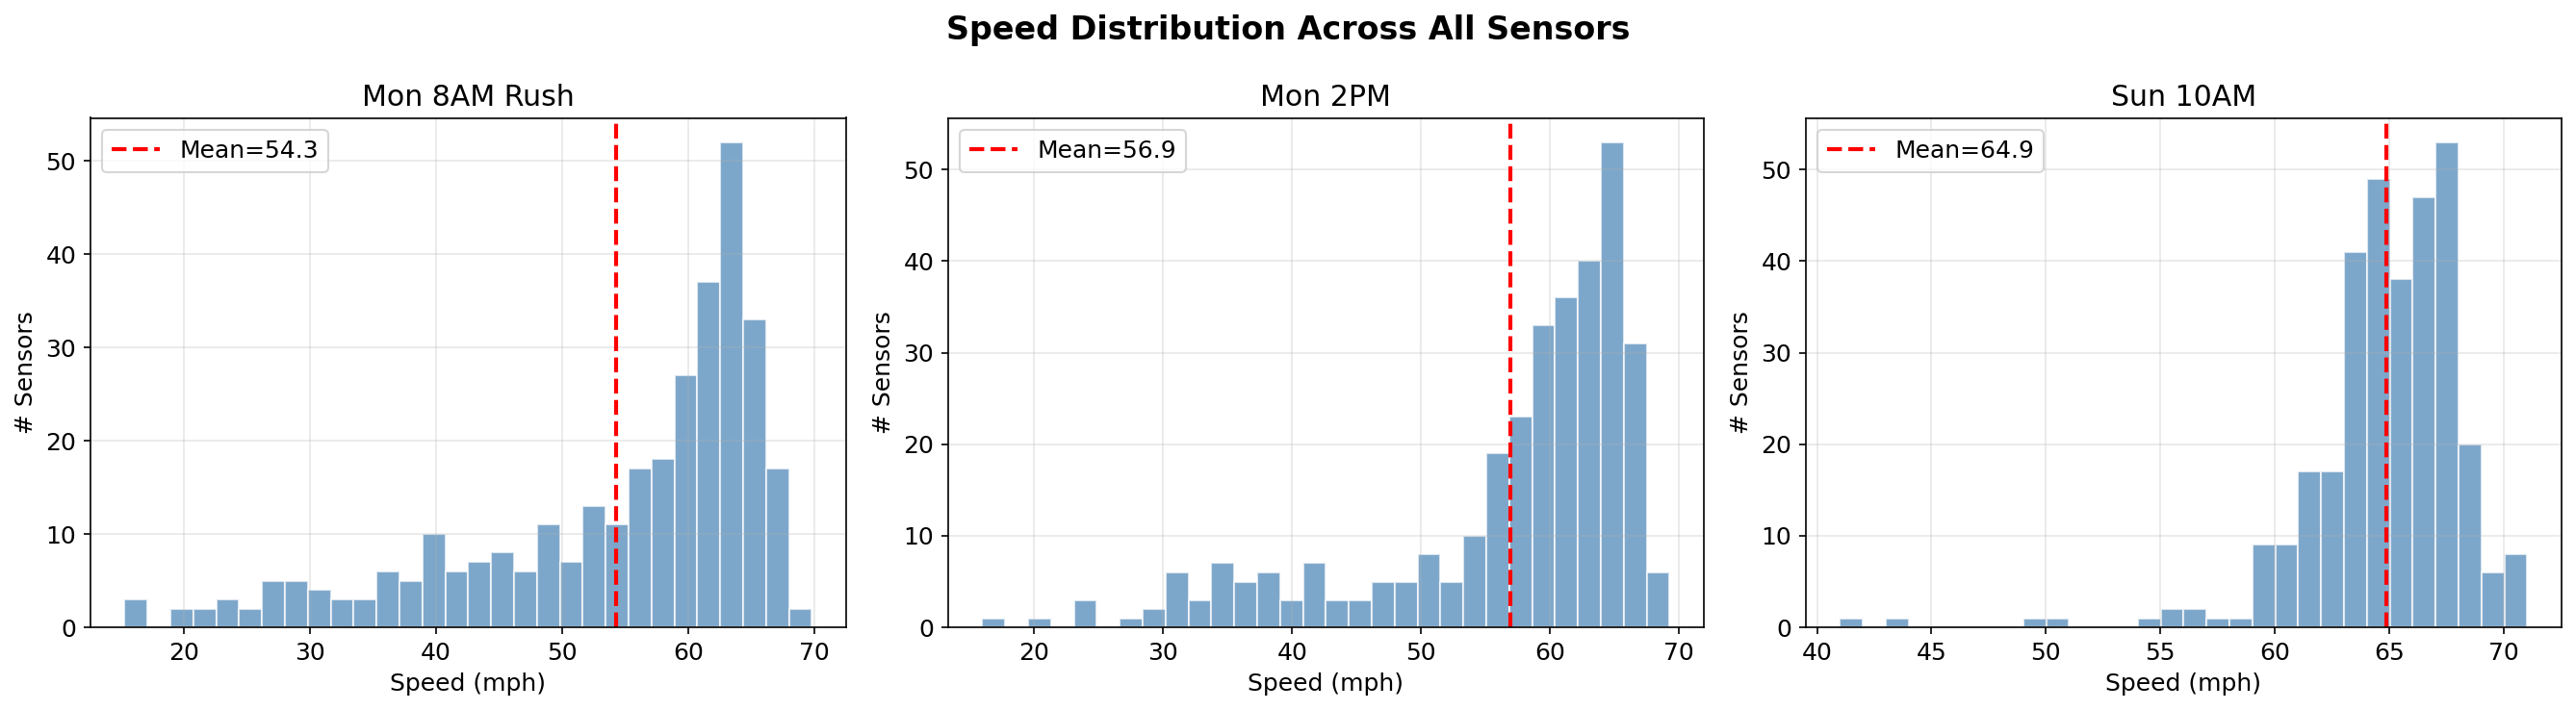

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Speed Distribution Across All Sensors', fontsize=16, fontweight='bold')
for ax, (day, hour, title) in zip(axes, [(0,8,'Mon 8AM Rush'), (0,14,'Mon 2PM'), (6,10,'Sun 10AM')]):
    p = predict_at(day, hour)
    if p is not None:
        speeds_60 = p[-1]  # 60-min ahead
        ax.hist(speeds_60, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
        ax.axvline(np.mean(speeds_60), color='red', lw=2, ls='--', label=f'Mean={np.mean(speeds_60):.1f}')
        ax.set_title(title); ax.set_xlabel('Speed (mph)'); ax.set_ylabel('# Sensors')
        ax.legend()
plt.tight_layout()
plt.savefig('/content/demo_speed_distribution.png', dpi=150, bbox_inches='tight'); plt.show()